In [149]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [150]:
import pandas as pd
import glob
import os

# Set the path to your folder
folder_path = '../pam/output/dump/'

# Get a list of all CSV files in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Read and concatenate all CSV files
combined_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Display the combined DataFrame
print(combined_df)

                Timestamp  Steps  PAM Score
0     1970-02-01 13:21:00      0     0.0625
1     1970-02-01 13:22:00      0     0.0000
2     1970-02-01 13:23:00      2     0.1875
3     1970-02-01 13:24:00      0     0.0625
4     1970-02-01 13:25:00      6     0.9375
...                   ...    ...        ...
5133  2025-05-26 13:45:00      0     0.0000
5134  2025-05-26 13:46:00      0     0.0000
5135  2025-05-26 13:47:00      0     0.0000
5136  2025-05-26 13:48:00     39     3.3125
5137  2025-05-26 13:49:00     57     2.9375

[5138 rows x 3 columns]


In [151]:
len(combined_df)

5138

In [152]:
combined_df = combined_df.drop(columns=['Timestamp'])

# --- (2) Select numeric columns and standardize ---
numeric_df = combined_df.select_dtypes(include='number')
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

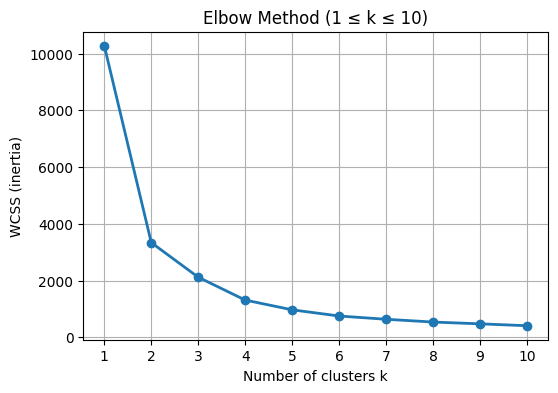

In [153]:

# --- (3) (Optional) Plot the Elbow curve to double-check your choice ---
#     If you already know “n_clusters” from a prior run, you can skip this block.
wcss = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, 'o-', linewidth=2)
plt.title('Elbow Method (1 ≤ k ≤ 10)')
plt.xlabel('Number of clusters k')
plt.ylabel('WCSS (inertia)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


In [154]:
def KMeans_clusters_with_N_clusters(n_clusters):
    # --- (4) Fit KMeans using the user‐specified n_clusters ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(scaled_data)
    
    # --- (5) Attach “cluster” labels back into the original DataFrame ---
    clustered_df = combined_df.copy()
    clustered_df['cluster'] = cluster_labels
    
    # If you want a DataFrame of standardized features + cluster ID:
    scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
    scaled_df['cluster'] = cluster_labels
    
    # # --- (6) Print out how many points ended up in each cluster ---
    # print("Cluster counts:")
    # print(clustered_df['cluster'].value_counts().sort_index())
    
    # --- (7) Compute centroids in original feature units ---
    centroids_std = kmeans.cluster_centers_                      # centroids in standardized space
    centroids_orig = scaler.inverse_transform(centroids_std)     # back to original units
    centroids_df = pd.DataFrame(centroids_orig, columns=numeric_df.columns)
    centroids_df['cluster'] = range(n_clusters)
    # print("\nCluster centroids (in original units):")
    # print(centroids_df)
    # 
    # --- (8) Visualize clusters on any two standardized features ---
    #      Here, you can pick any two column names from numeric_df.columns.
    #      E.g. if numeric_df.columns = ['A','B','C','D'], you might choose 'B' vs 'D'.
    
    feat_x = numeric_df.columns[0]   # e.g. first numeric column
    feat_y = numeric_df.columns[1]   # e.g. second numeric column
    
    plt.figure(figsize=(7, 5))
    for cid in range(n_clusters):
        mask = (cluster_labels == cid)
        plt.scatter(
            scaled_data[mask, numeric_df.columns.get_loc(feat_x)],
            scaled_data[mask, numeric_df.columns.get_loc(feat_y)],
            s=30,
            alpha=0.6,
            label=f'Cluster {cid}'
        )
    
    # Plot centroids (in standardized space)
    plt.scatter(
        centroids_std[:, numeric_df.columns.get_loc(feat_x)],
        centroids_std[:, numeric_df.columns.get_loc(feat_y)],
        s=200,
        c='red',
        marker='X',
        edgecolor='k',
        label='Centroids'
    )
    
    plt.title(f'KMeans Clustering (k={n_clusters}) on "{feat_x}" vs "{feat_y}"')
    plt.xlabel(f'{feat_x} (standardized)')
    plt.ylabel(f'{feat_y} (standardized)')
    plt.legend()
    plt.grid(True)
    return plt

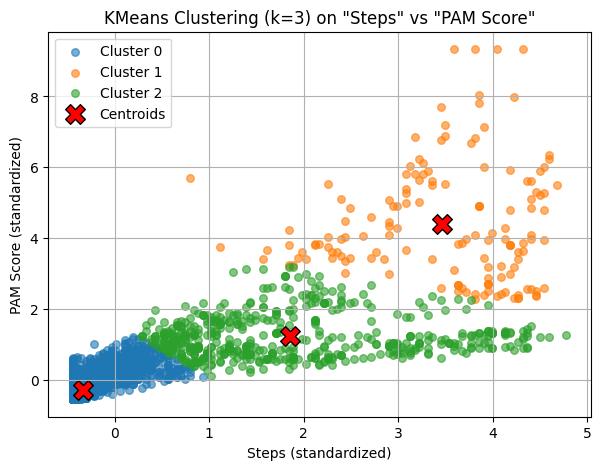

In [155]:

# --- (A) USER SETS THIS: number of clusters to fit ---
n_clusters = 3   # ← change this to 2, 3, 5, etc.
KMeans_clusters_with_N_clusters(n_clusters=n_clusters).show()

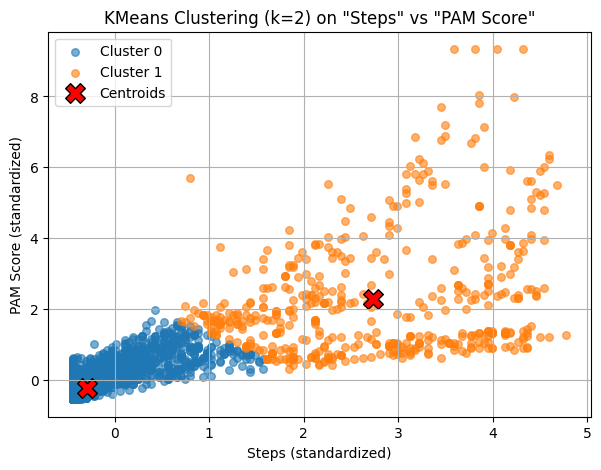

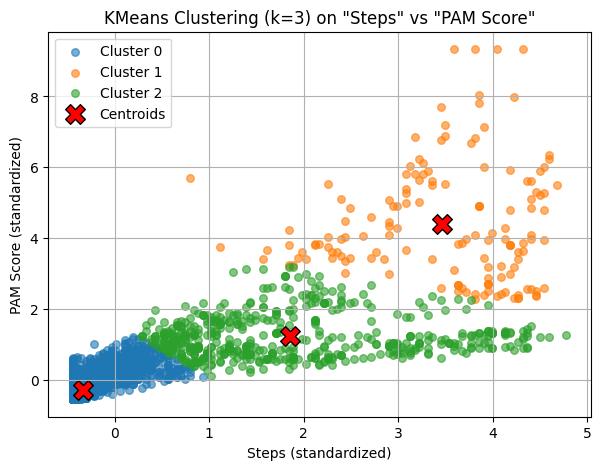

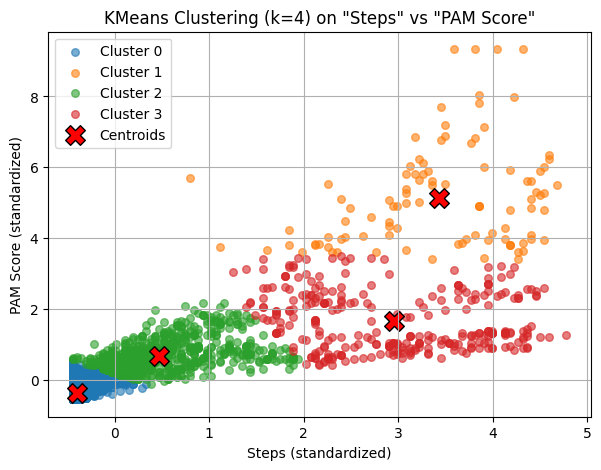

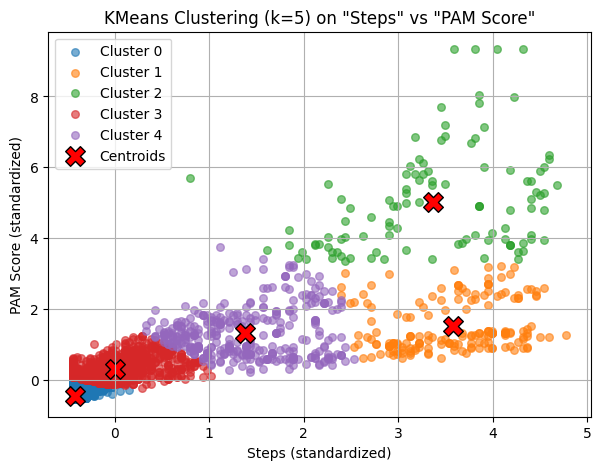

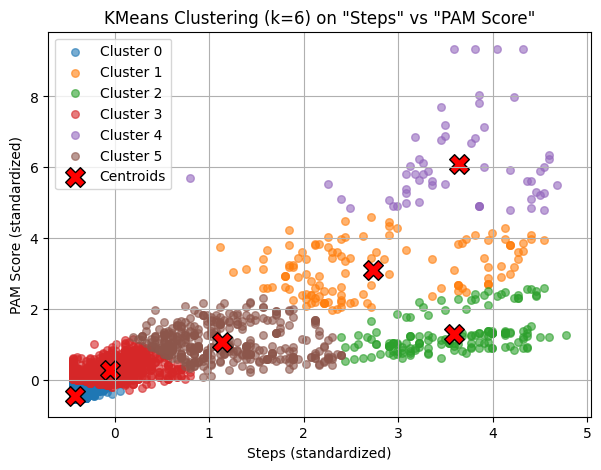

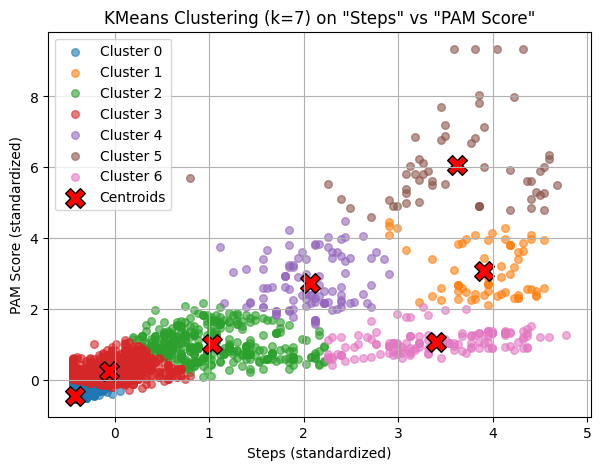

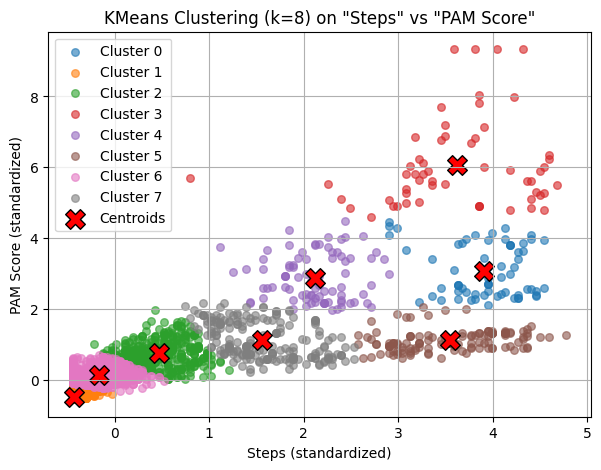

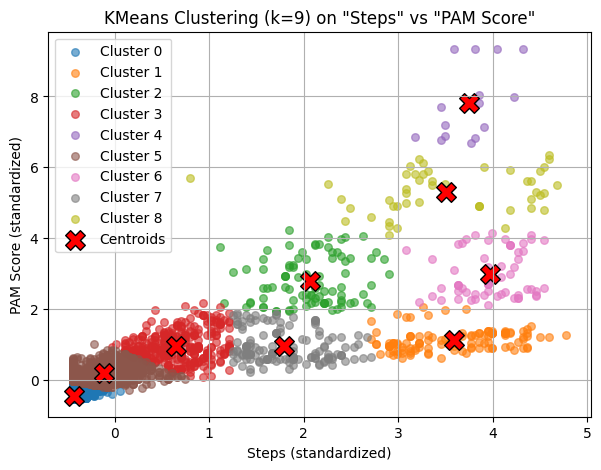

In [156]:
for i in range(2,10):
    KMeans_clusters_with_N_clusters(n_clusters=i).show()